In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from matplotlib import font_manager as fm

In [2]:
data = pd.read_excel("data/Diagramme_Gantt_Blog_Web.xlsx", sheet_name='Sheet1', header=0)
print(data)

    N° de la tâche Date de début Date de fin  \
0                1    01/01/2025  10/01/2025   
1                2    11/01/2025  20/01/2025   
2                3    21/01/2025  31/01/2025   
3                4    01/02/2025  15/02/2025   
4                5    16/02/2025  15/03/2025   
5                6    16/03/2025  05/04/2025   
6                7    06/04/2025  15/04/2025   
7                8    16/04/2025  20/04/2025   
8                9    21/04/2025  30/04/2025   
9               10    01/05/2025  10/05/2025   
10              11    11/05/2025  31/12/2025   
11              12    11/05/2025  31/12/2025   
12              13    11/05/2025  31/12/2025   
13              14    01/06/2025  31/12/2025   
14              15    01/09/2025  31/10/2025   
15              16    01/12/2025  20/12/2025   
16              17    21/12/2025  31/12/2025   

                                      Nom de la tâche  Durée (jours)  
0   Analyse des besoins et définition des objectif...           

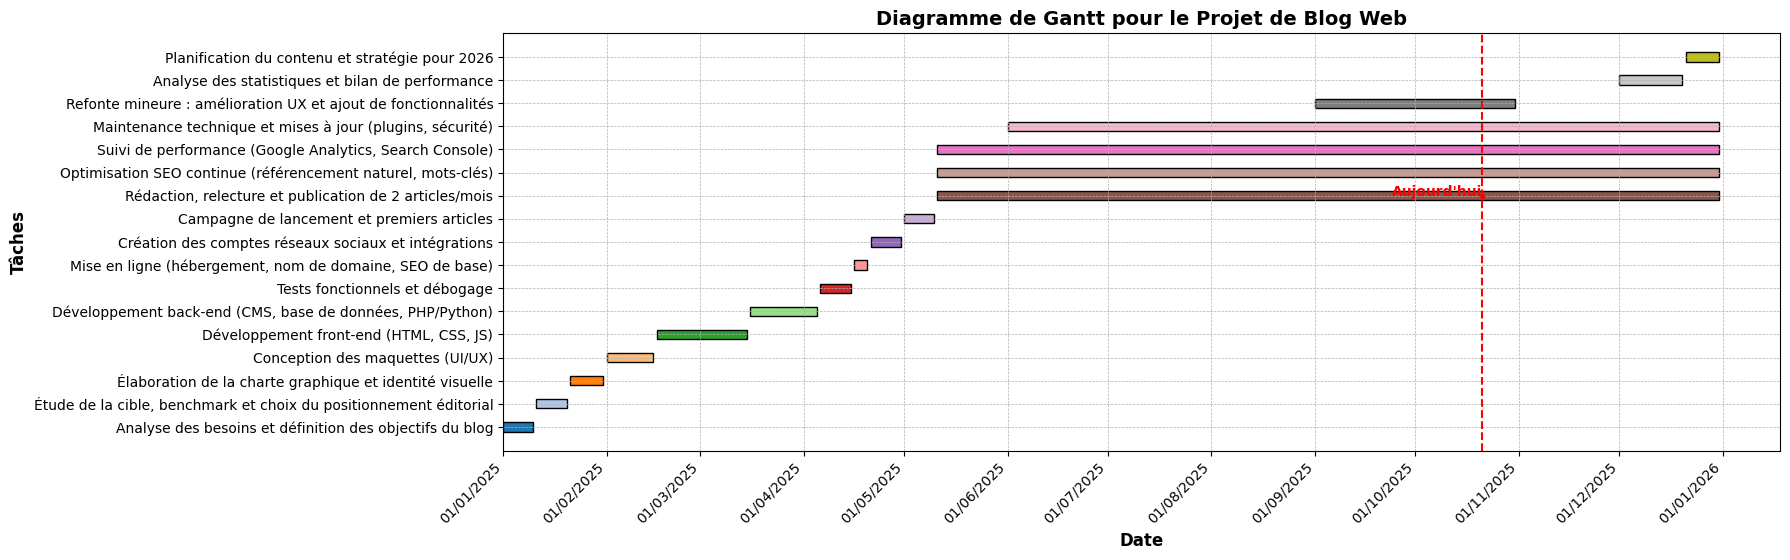

In [9]:
df = pd.DataFrame(data)
df.dropna(subset=['Date de début', 'Date de fin'], inplace=True)
colors = plt.cm.tab20.colors

df['Start Date'] = pd.to_datetime(df['Date de début'], format='%d/%m/%Y', errors='coerce')
df['End Date'] = pd.to_datetime(df['Date de fin'], format='%d/%m/%Y', errors='coerce')


fig, ax = plt.subplots(figsize=(18, 6))

for i, task in df.iterrows():
    ax.barh(task['Nom de la tâche'],(task['End Date']- task['Start Date']).days, left= task['Start Date'], height=0.4, color=colors[i % len(colors)], edgecolor='black')

ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Tâches', fontsize=12, fontweight='bold')
ax.set_title('Diagramme de Gantt pour le Projet de Blog Web', fontsize=14, fontweight='bold')

today = pd.to_datetime(dt.datetime.today().strftime('%Y-%m-%d'))
ax.axvline(today, color='red', linestyle='--', label="Aujourd'hui", linewidth=1.5)
ax.plot(today, len(df)//2+2, 'ro', markersize=3)
ax.text(today, len(df)//2+2, 'Aujourd\'hui', color='red', fontsize=10, fontweight='bold', ha='right')

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()